# A - Evaluation

In [22]:
import torch
import numpy as np
import os

from TD3 import TD3
from spacecraft_flex_ft_obs_noeta_env_MRP import FlexibleSpacecraft
from flex_utils import ReplayBuffer, plot_states, plot_omega, plot_p, plot_Tr, plot_eta, plot_d, performance_old, performance_steadystate, performance_transient

%load_ext autoreload
%autoreload 2
from datetime import datetime
print('Runtime:', datetime.now().strftime('%Y-%m-%d %H:%M:%S'))


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Runtime: 2026-06-23 18:42:59


### Model Path

C  
260105 1 15040

In [23]:
# device = torch.device("cpu")
# date = '251113'
# num_train = "1_cont"   # Saved training number

date = '260105'
num_train = "1"

save_path = './saved_model_td3/'+date+'/taining_num_'+num_train    # Model save path
os.makedirs(save_path, exist_ok=True)                       # exist_ok=True: do nothing if directory already exists


### Enter Elite Model Number

In [24]:
save_path_elite = os.path.join(save_path, f'elite_{int(15040)}')

### Check CUDA and MPS (Apple Silicon)

In [25]:
# device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
# print(f'rolling on {torch.cuda.get_device_name(torch.cuda.current_device())}')

print(f"CUDA available: {torch.cuda.is_available()}")

# Check GPU count
if torch.cuda.is_available():
    gpu_count = torch.cuda.device_count()
    print(f"GPU count: {gpu_count}")
    
    # View each GPU info
    for i in range(gpu_count):
        print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
        print(f"GPU {i} memory: {torch.cuda.get_device_properties(i).total_memory / 1024**3:.2f} GB")

if torch.cuda.is_available():
    # Set which GPU to use (e.g., GPU 0)
    torch.cuda.set_device(0)  # Select which GPU
    device = torch.device("cuda:0")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device=torch.device('mps' if (torch.backends.mps.is_available()) else 'cpu')
    print("Using", device)
else:
    device = torch.device("cpu")
    print("Using CPU")

CUDA available: False
Using mps


### Hyperparameters

In [26]:
# Hyperparameters
actor_lr = 3e-4
critic_lr = 3e-4
num_episodes = 10000
gamma = 0.99
tau = 0.01  # Soft update param, range 0~1, tau=1 means full copy to target networks
buffer_size = 1000000
minimal_size = 1000
batch_size = 250
exploration_noise = 0.1  # Gaussian noise std dev
policy_noise = 0.2
noise_clip = 0.5
env_time = 200   # Episode duration: each step = 1s, 100 steps total per episode
dt = 1
delay = 3

# Learning rate decay: after every 300 episodes, LR is multiplied by factor (1 = no decay)
lr_step_size = 300 
lr_gamma = 1


env = FlexibleSpacecraft(env_time, dt)
state = env.reset()

replay_buffer = ReplayBuffer(buffer_size)
state_dim = state.shape[0]
action_dim = env.Tr_sol.shape[0]
action_bound = env.umax
# Actor input = state + state-reference error, so input dim = 2 * state_dim
agent = TD3(state_dim, action_dim, action_bound, policy_noise, noise_clip, actor_lr, critic_lr, tau, gamma, device, delay, lr_step_size, lr_gamma)

### Load Saved Model

In [27]:
# load_path = './saved_model_td3/'+date+'/taining_num_'+num_train
# agent.load_model_cpu(load_path)
agent.load_model_cpu(save_path_elite)

### Test with Loaded Agent

### Scenario 0 Pure Baseline (no noise, no disturbance): TD3 only


reward for this episode: 18527.641633958887


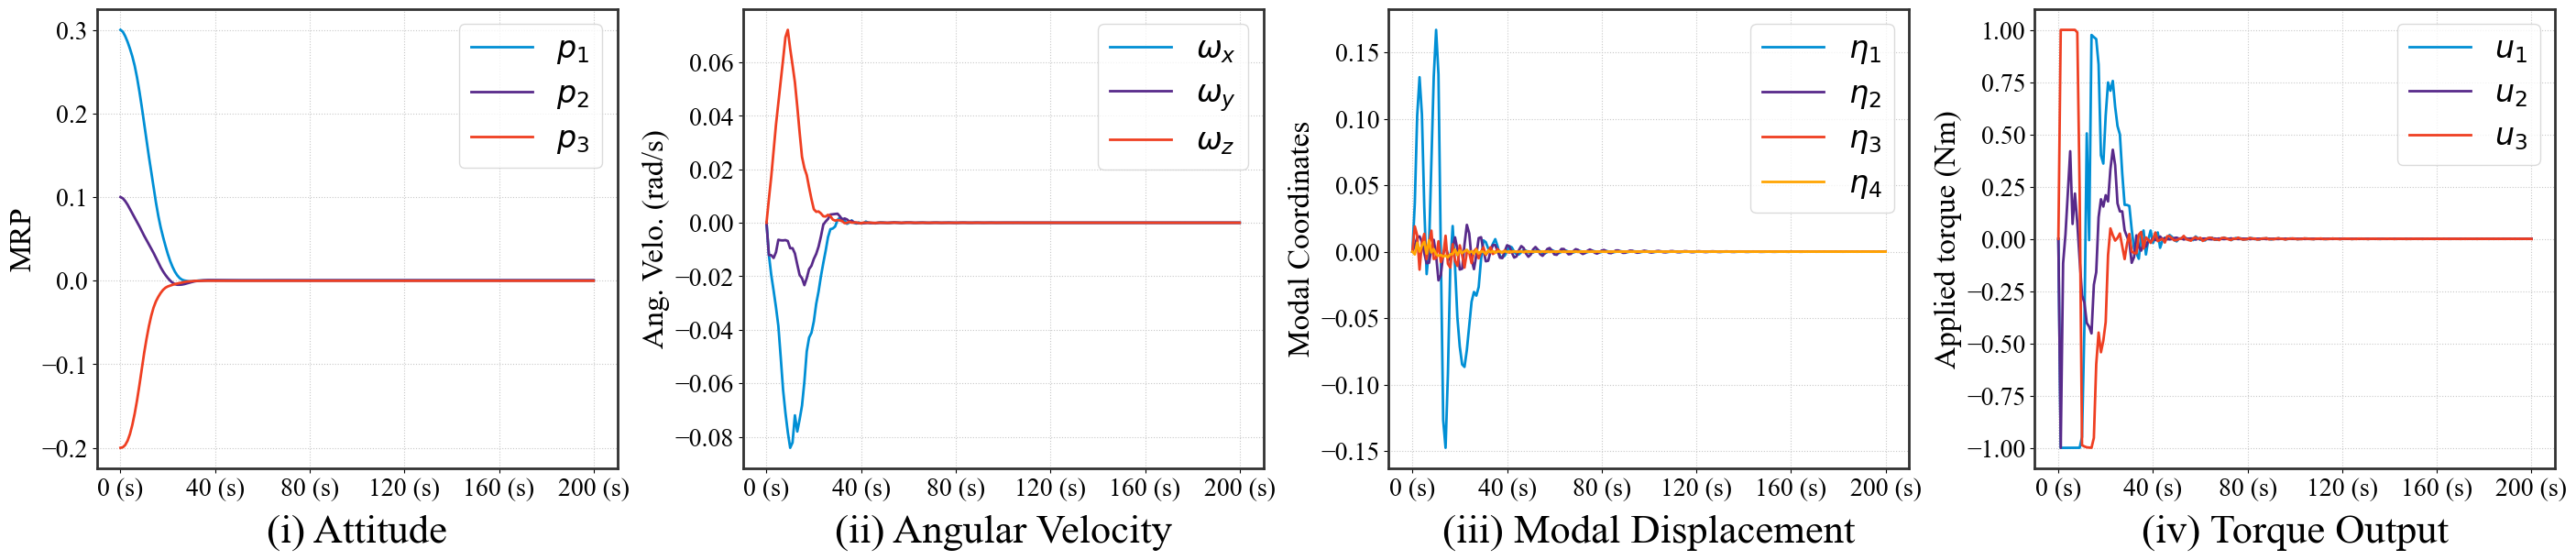

Earliest time MRP converges within 0.01 (s): 24
Earliest time MRP converges within 0.005 (s): 25
Earliest time angular velocity converges within 0.01 (s): 26
Earliest time angular velocity converges within 0.005 (s): 27
Maximum modal displacement: 0.167
Earliest time modal displacement converges within 0.01 (s): 30
Earliest time modal displacement converges within 0.005 (s): 36
  Steady-state Metrics (t > 160s)
  SS MRP ||p||_inf          : 0.000457
  SS Ang. Velo. ||ω||_inf   : 0.000007 rad/s
  SS Modal Disp. RMS        : 0.000050
  SS Control Torque RMS     : 0.000616 Nm
  Transient / Full-Trajectory Metrics
  MRP converge to 0.01 time  : 24s
  MRP converge to 0.005 time : 25s
  Full Ang. Velo. ||ω||_inf  : 0.084143 rad/s
  Full Modal Disp. RMS       : 0.031322
  Full Control Torque RMS    : 0.418279 Nm


{'converge_time_01': np.int64(24),
 'converge_time_005': np.int64(25),
 'omega_inf_max': np.float64(0.08414304631382877),
 'eta_rms': np.float64(0.0313222718410744),
 'torque_rms': np.float64(0.41827859928026095)}

In [28]:
mode = 'Scenario0'
episode_return = 0
env_test = FlexibleSpacecraft(200, 1)
state = env_test.reset(mode)
done = False
while not done:
    action = agent.take_action(state)
    env_test.Tr_sol = np.column_stack((env_test.Tr_sol, action))
    next_state, reward, done, _ = env_test.step(action)
    state = next_state
    episode_return += reward

print(f'reward for this episode: {episode_return}')
plot_states(env_test.t_sol, env_test.X_sol, env_test.Tr_sol, MDPI_style=True)
performance_old(env_test.t_sol, env_test.X_sol)
performance_steadystate(env_test.t_sol, env_test.X_sol, env_test.Tr_sol)
performance_transient(env_test.t_sol, env_test.X_sol, env_test.Tr_sol)


### Scenario 1 Baseline Attitude Reorientation: 

reward for this episode: 18142.726210370478


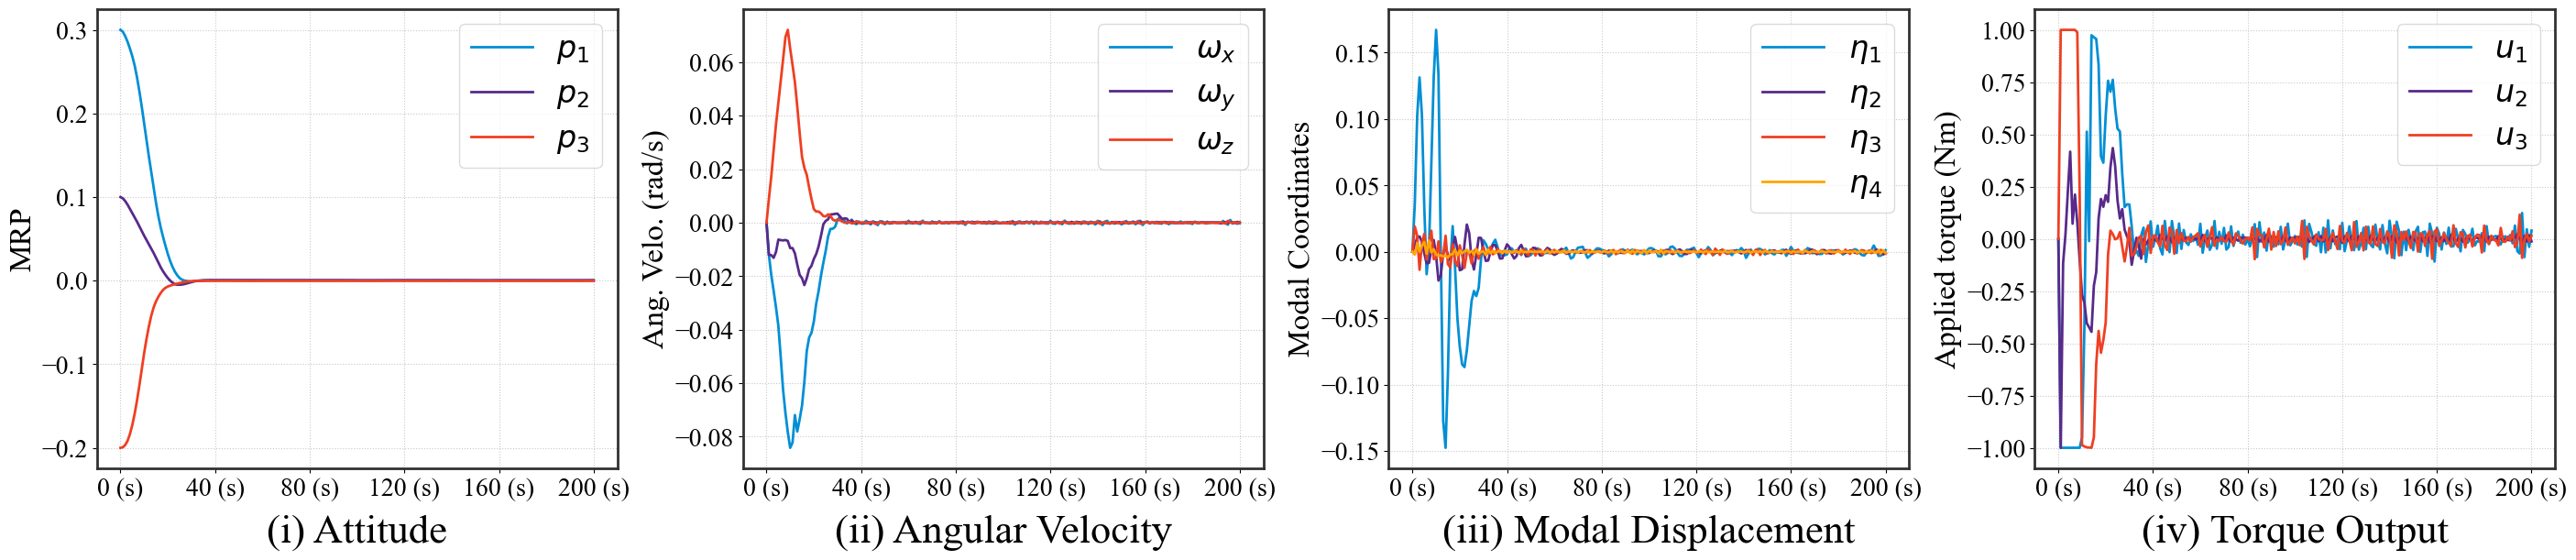

Earliest time MRP converges within 0.01 (s): 24
Earliest time MRP converges within 0.005 (s): 25
Earliest time angular velocity converges within 0.01 (s): 26
Earliest time angular velocity converges within 0.005 (s): 27
Maximum modal displacement: 0.167
Earliest time modal displacement converges within 0.01 (s): 30
Earliest time modal displacement converges within 0.005 (s): 68
  Steady-state Metrics (t > 160s)
  SS MRP ||p||_inf          : 0.000544
  SS Ang. Velo. ||ω||_inf   : 0.000997 rad/s
  SS Modal Disp. RMS        : 0.002236
  SS Control Torque RMS     : 0.057957 Nm
  Transient / Full-Trajectory Metrics
  MRP converge to 0.01 time  : 24s
  MRP converge to 0.005 time : 25s
  Full Ang. Velo. ||ω||_inf  : 0.084152 rad/s
  Full Modal Disp. RMS       : 0.031410
  Full Control Torque RMS    : 0.422168 Nm


{'converge_time_01': np.int64(24),
 'converge_time_005': np.int64(25),
 'omega_inf_max': np.float64(0.08415245151340446),
 'eta_rms': np.float64(0.0314097274529311),
 'torque_rms': np.float64(0.4221675523387823)}

In [29]:
mode = 'Scenario1'
episode_return = 0
env_test = FlexibleSpacecraft(200, 1, use_measurement_noise=True)
np.random.seed(42)
state = env_test.reset(mode)
done = False
while not done:
    action = agent.take_action(state)
    env_test.Tr_sol = np.column_stack((env_test.Tr_sol, action))
    next_state, reward, done, _ = env_test.step(action)
    state = next_state
    episode_return += reward

print(f'reward for this episode: {episode_return}')
plot_states(env_test.t_sol, env_test.X_sol, env_test.Tr_sol, MDPI_style=True)
performance_old(env_test.t_sol, env_test.X_sol)
performance_steadystate(env_test.t_sol, env_test.X_sol, env_test.Tr_sol)
performance_transient(env_test.t_sol, env_test.X_sol, env_test.Tr_sol)
# plot_d(env_test.t_sol, env_test.d_sol)


### Scenario 2 Non-zero Initial Angular Velocity

reward for this episode: 18117.16275799272


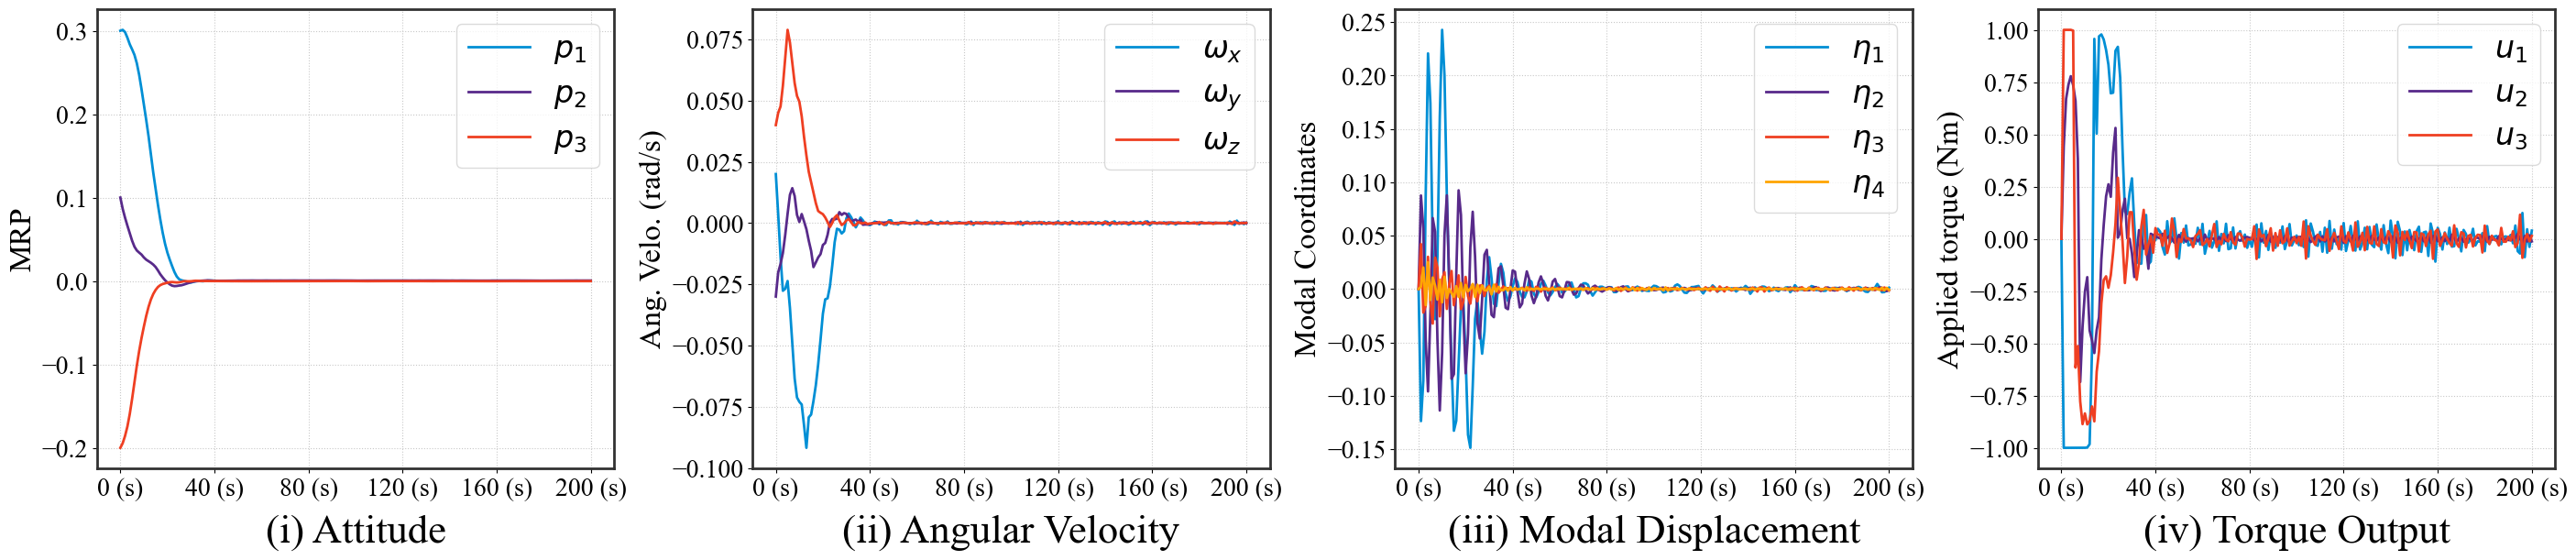

Earliest time MRP converges within 0.01 (s): 24
Earliest time MRP converges within 0.005 (s): 27
Earliest time angular velocity converges within 0.01 (s): 25
Earliest time angular velocity converges within 0.005 (s): 26
Maximum modal displacement: 0.243
Earliest time modal displacement converges within 0.01 (s): 56
Earliest time modal displacement converges within 0.005 (s): 75
  Steady-state Metrics (t > 160s)
  SS MRP ||p||_inf          : 0.000544
  SS Ang. Velo. ||ω||_inf   : 0.000995 rad/s
  SS Modal Disp. RMS        : 0.002250
  SS Control Torque RMS     : 0.057943 Nm
  Transient / Full-Trajectory Metrics
  MRP converge to 0.01 time  : 24s
  MRP converge to 0.005 time : 27s
  Full Ang. Velo. ||ω||_inf  : 0.091779 rad/s
  Full Modal Disp. RMS       : 0.048732
  Full Control Torque RMS    : 0.442860 Nm


{'converge_time_01': np.int64(24),
 'converge_time_005': np.int64(27),
 'omega_inf_max': np.float64(0.09177871562841487),
 'eta_rms': np.float64(0.04873218464958289),
 'torque_rms': np.float64(0.4428604964114494)}

In [30]:
mode = 'Scenario2'
episode_return = 0
env_test = FlexibleSpacecraft(200, 1, use_measurement_noise=True)
np.random.seed(42)
state = env_test.reset(mode)
done = False
while not done:
    action = agent.take_action(state)
    env_test.Tr_sol = np.column_stack((env_test.Tr_sol, action))
    next_state, reward, done, _ = env_test.step(action)
    state = next_state
    episode_return += reward

print(f'reward for this episode: {episode_return}')
plot_states(env_test.t_sol, env_test.X_sol, env_test.Tr_sol, MDPI_style=True)
performance_old(env_test.t_sol, env_test.X_sol)
performance_steadystate(env_test.t_sol, env_test.X_sol, env_test.Tr_sol)
performance_transient(env_test.t_sol, env_test.X_sol, env_test.Tr_sol)
# plot_d(env_test.t_sol, env_test.d_sol)



### Scenario 3 (Modified Moment of Inertia):

reward for this episode: 17826.80123870492


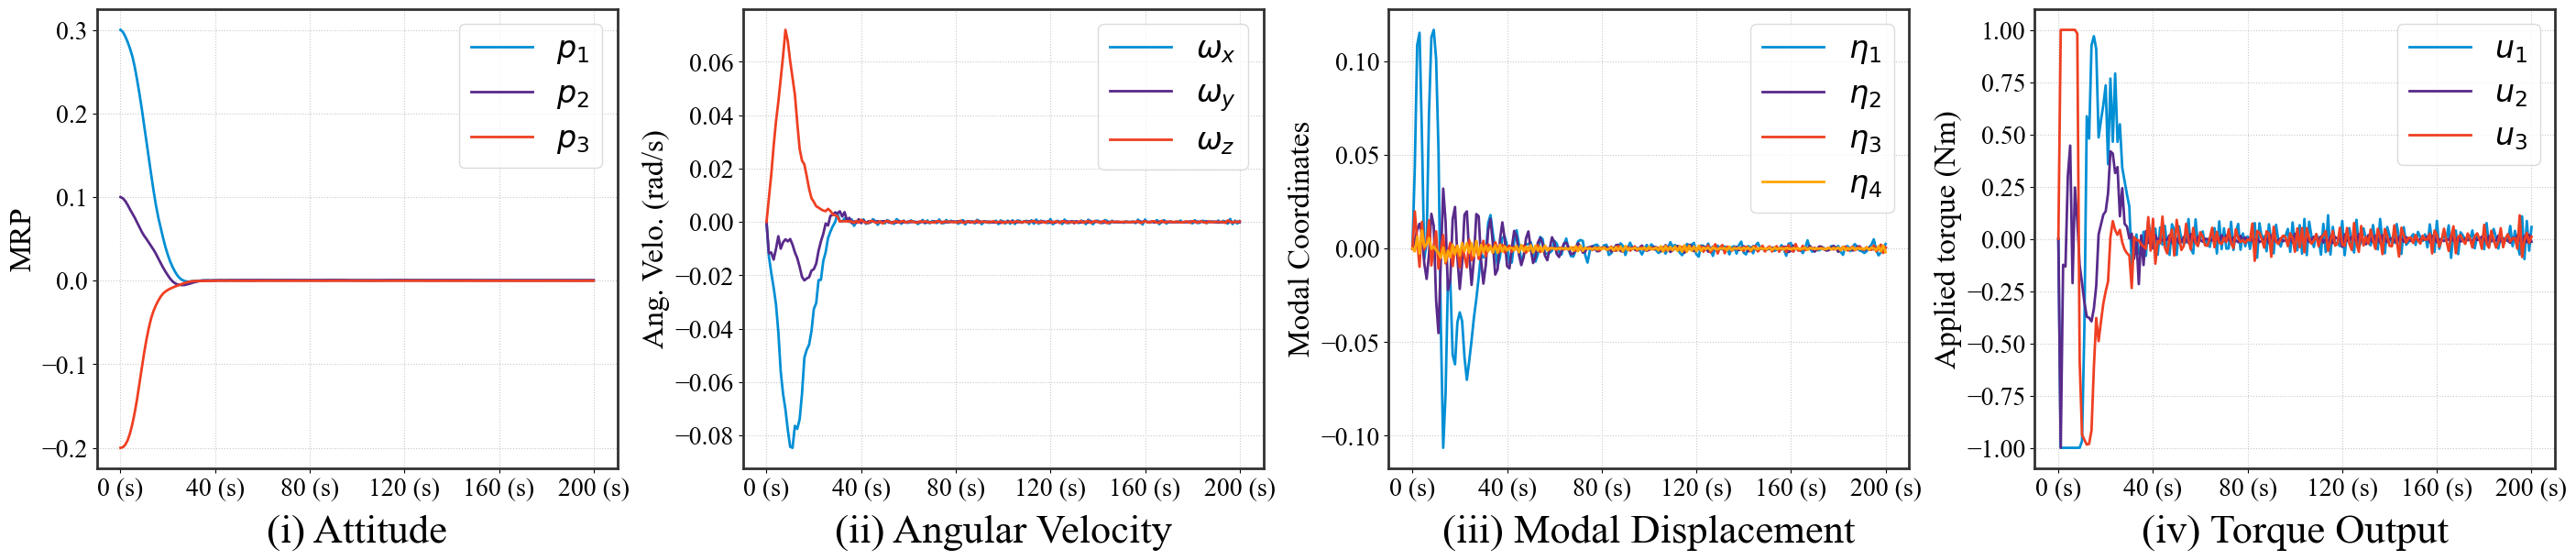

Earliest time MRP converges within 0.01 (s): 24
Earliest time MRP converges within 0.005 (s): 28
Earliest time angular velocity converges within 0.01 (s): 26
Earliest time angular velocity converges within 0.005 (s): 27
Maximum modal displacement: 0.117
Earliest time modal displacement converges within 0.01 (s): 42
Earliest time modal displacement converges within 0.005 (s): 75
  Steady-state Metrics (t > 160s)
  SS MRP ||p||_inf          : 0.000655
  SS Ang. Velo. ||ω||_inf   : 0.001117 rad/s
  SS Modal Disp. RMS        : 0.002323
  SS Control Torque RMS     : 0.063331 Nm
  Transient / Full-Trajectory Metrics
  MRP converge to 0.01 time  : 24s
  MRP converge to 0.005 time : 28s
  Full Ang. Velo. ||ω||_inf  : 0.084649 rad/s
  Full Modal Disp. RMS       : 0.026316
  Full Control Torque RMS    : 0.417426 Nm


{'converge_time_01': np.int64(24),
 'converge_time_005': np.int64(28),
 'omega_inf_max': np.float64(0.08464902536382637),
 'eta_rms': np.float64(0.026315693900623733),
 'torque_rms': np.float64(0.41742602725773487)}

In [31]:
mode = 'Scenario3'
episode_return = 0
env_test = FlexibleSpacecraft(200, 1, use_measurement_noise=True, use_param_uncertainty=True, use_disturbance=True)
np.random.seed(42)
state = env_test.reset(mode)
done = False
while not done:
    action = agent.take_action(state)
    env_test.Tr_sol = np.column_stack((env_test.Tr_sol, action))
    next_state, reward, done, _ = env_test.step(action)
    state = next_state
    episode_return += reward

print(f'reward for this episode: {episode_return}')
plot_states(env_test.t_sol, env_test.X_sol, env_test.Tr_sol, MDPI_style=True)
performance_old(env_test.t_sol, env_test.X_sol)
performance_steadystate(env_test.t_sol, env_test.X_sol, env_test.Tr_sol)
performance_transient(env_test.t_sol, env_test.X_sol, env_test.Tr_sol)
# plot_d(env_test.t_sol, env_test.d_sol)


### Scenario 4 performed by TD3 only

reward for this episode: 2578.132365667791


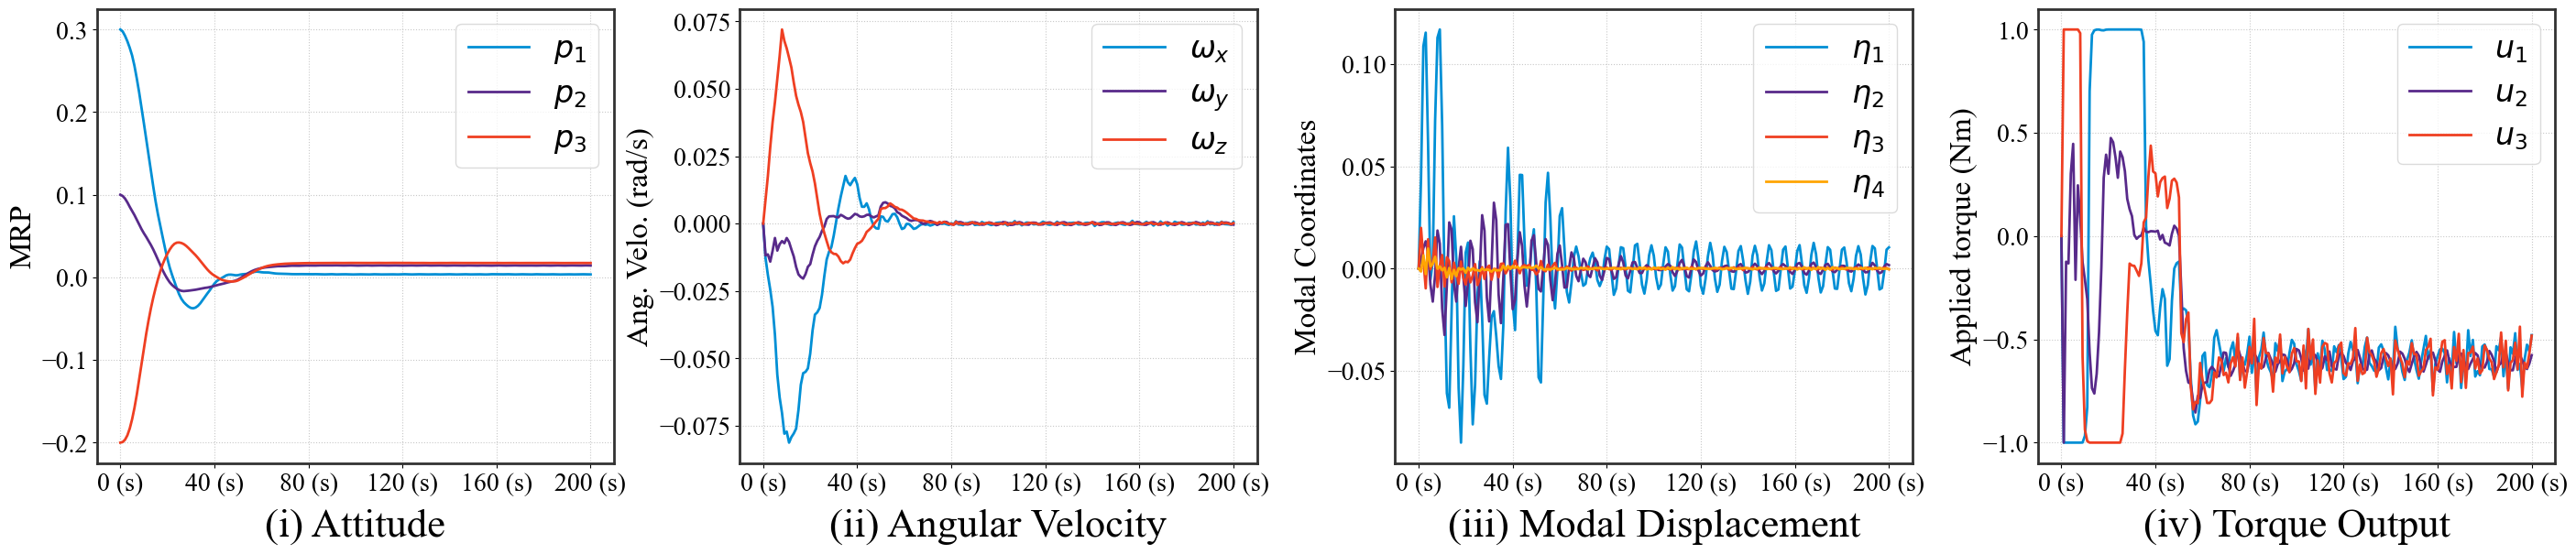

Earliest time MRP converges within 0.01 (s): None
Earliest time MRP converges within 0.005 (s): None
Earliest time angular velocity converges within 0.01 (s): 41
Earliest time angular velocity converges within 0.005 (s): 60
Maximum modal displacement: 0.117
Earliest time modal displacement converges within 0.01 (s): None
Earliest time modal displacement converges within 0.005 (s): None
  Steady-state Metrics (t > 160s)
  SS MRP ||p||_inf          : 0.017458
  SS Ang. Velo. ||ω||_inf   : 0.000854 rad/s
  SS Modal Disp. RMS        : 0.008434
  SS Control Torque RMS     : 1.045275 Nm
  Transient / Full-Trajectory Metrics
  MRP converge to 0.01 time  : Nones
  MRP converge to 0.005 time : Nones
  Full Ang. Velo. ||ω||_inf  : 0.081243 rad/s
  Full Modal Disp. RMS       : 0.029079
  Full Control Torque RMS    : 1.086030 Nm


{'converge_time_01': None,
 'converge_time_005': None,
 'omega_inf_max': np.float64(0.08124278477857128),
 'eta_rms': np.float64(0.029078572767190065),
 'torque_rms': np.float64(1.0860296141655765)}

In [32]:
mode = 'Scenario4'
episode_return = 0
env_test = FlexibleSpacecraft(200, 1, use_measurement_noise=True, use_param_uncertainty=True, use_disturbance=True)
np.random.seed(42)
state = env_test.reset(mode)
done = False
while not done:
    action = agent.take_action(state)
    env_test.Tr_sol = np.column_stack((env_test.Tr_sol, action))
    next_state, reward, done, _ = env_test.step(action)
    state = next_state
    episode_return += reward

print(f'reward for this episode: {episode_return}')
plot_states(env_test.t_sol, env_test.X_sol, env_test.Tr_sol, MDPI_style=True)
performance_old(env_test.t_sol, env_test.X_sol)
# plot_d(env_test.t_sol, env_test.d_sol)
performance_steadystate(env_test.t_sol, env_test.X_sol, env_test.Tr_sol)
performance_transient(env_test.t_sol, env_test.X_sol, env_test.Tr_sol)

### Scenario 4 performed by TD3+AFT （new flexible s）

reward for this episode: 11332.477878794078


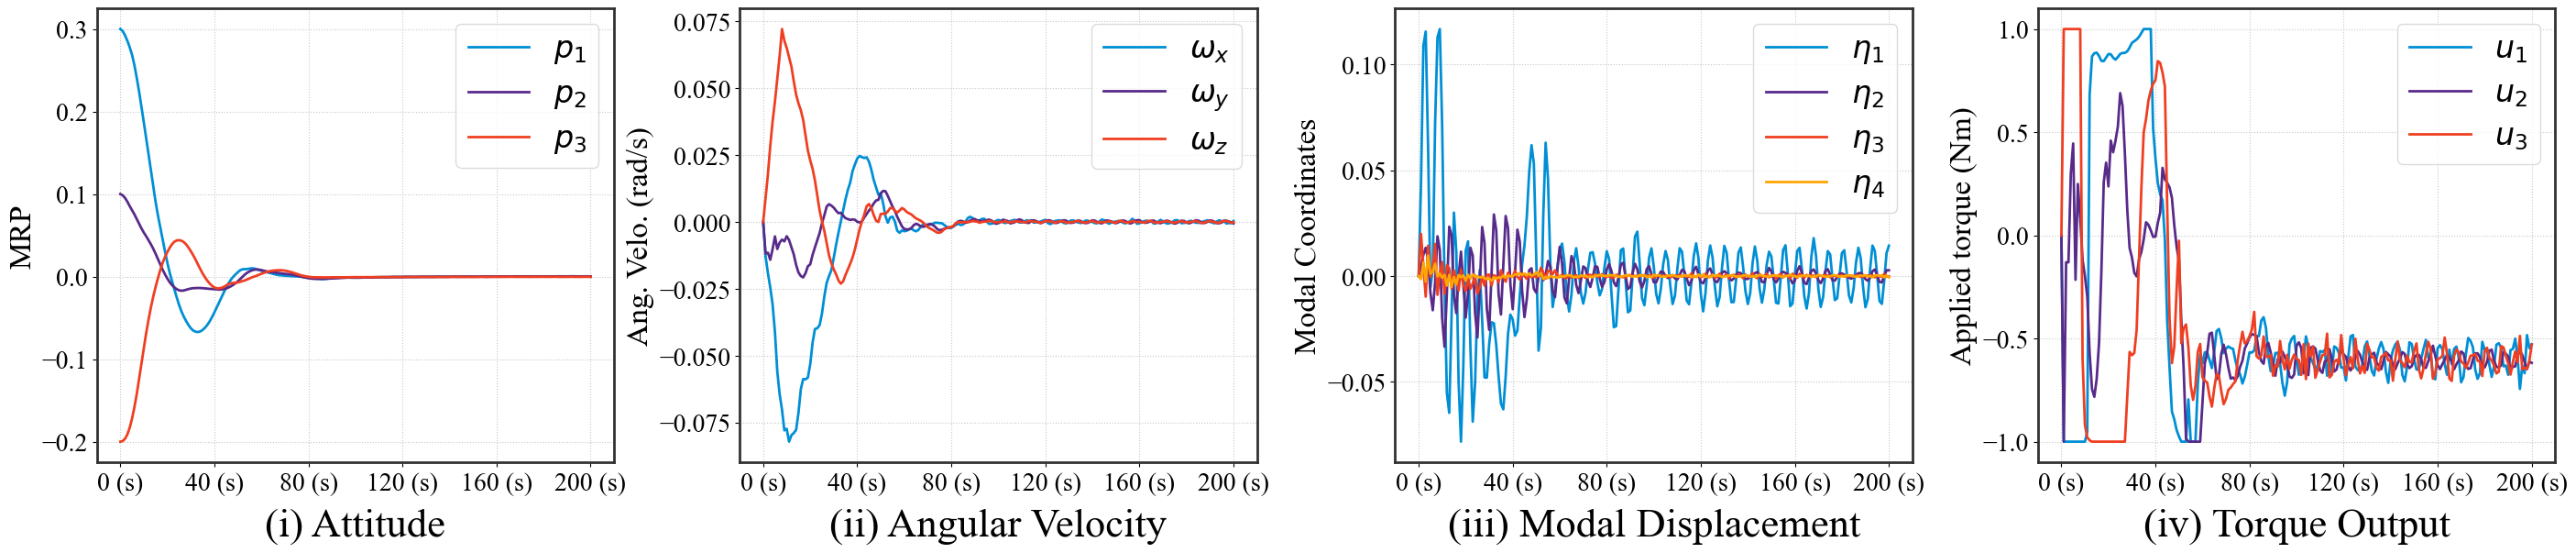

Earliest time MRP converges within 0.01 (s): 57
Earliest time MRP converges within 0.005 (s): 74
Earliest time angular velocity converges within 0.01 (s): 53
Earliest time angular velocity converges within 0.005 (s): 60
Maximum modal displacement: 0.117
Earliest time modal displacement converges within 0.01 (s): None
Earliest time modal displacement converges within 0.005 (s): None
  Steady-state Metrics (t > 160s)
  SS MRP ||p||_inf          : 0.000404
  SS Ang. Velo. ||ω||_inf   : 0.000754 rad/s
  SS Modal Disp. RMS        : 0.010406
  SS Control Torque RMS     : 1.044244 Nm
  Transient / Full-Trajectory Metrics
  MRP converge to 0.01 time  : 57s
  MRP converge to 0.005 time : 74s
  Full Ang. Velo. ||ω||_inf  : 0.082192 rad/s
  Full Modal Disp. RMS       : 0.029089
  Full Control Torque RMS    : 1.118126 Nm


{'converge_time_01': np.int64(57),
 'converge_time_005': np.int64(74),
 'omega_inf_max': np.float64(0.08219203993755275),
 'eta_rms': np.float64(0.029088887753086823),
 'torque_rms': np.float64(1.1181255627393336)}

In [33]:
mode = 'Scenario4'
episode_return = 0
env_test = FlexibleSpacecraft(200, 1, use_measurement_noise=True, use_param_uncertainty=True, use_disturbance=True)
np.random.seed(42)
state = env_test.reset(mode)
done = False
while not done:
    unom = agent.take_action(state)
    action = env_test.controllerTD3AFT(unom)
    env_test.Tr_sol = np.column_stack((env_test.Tr_sol, action))
    next_state, reward, done, _ = env_test.step(action)
    state = next_state
    episode_return += reward

print(f'reward for this episode: {episode_return}')
plot_states(env_test.t_sol, env_test.X_sol, env_test.Tr_sol, MDPI_style=True)
performance_old(env_test.t_sol, env_test.X_sol)
# plot_d(env_test.t_sol, env_test.d_sol)
performance_steadystate(env_test.t_sol, env_test.X_sol, env_test.Tr_sol)
performance_transient(env_test.t_sol, env_test.X_sol, env_test.Tr_sol)

### Scenario 4 performed by PD

reward for this episode: 1417.824265805974


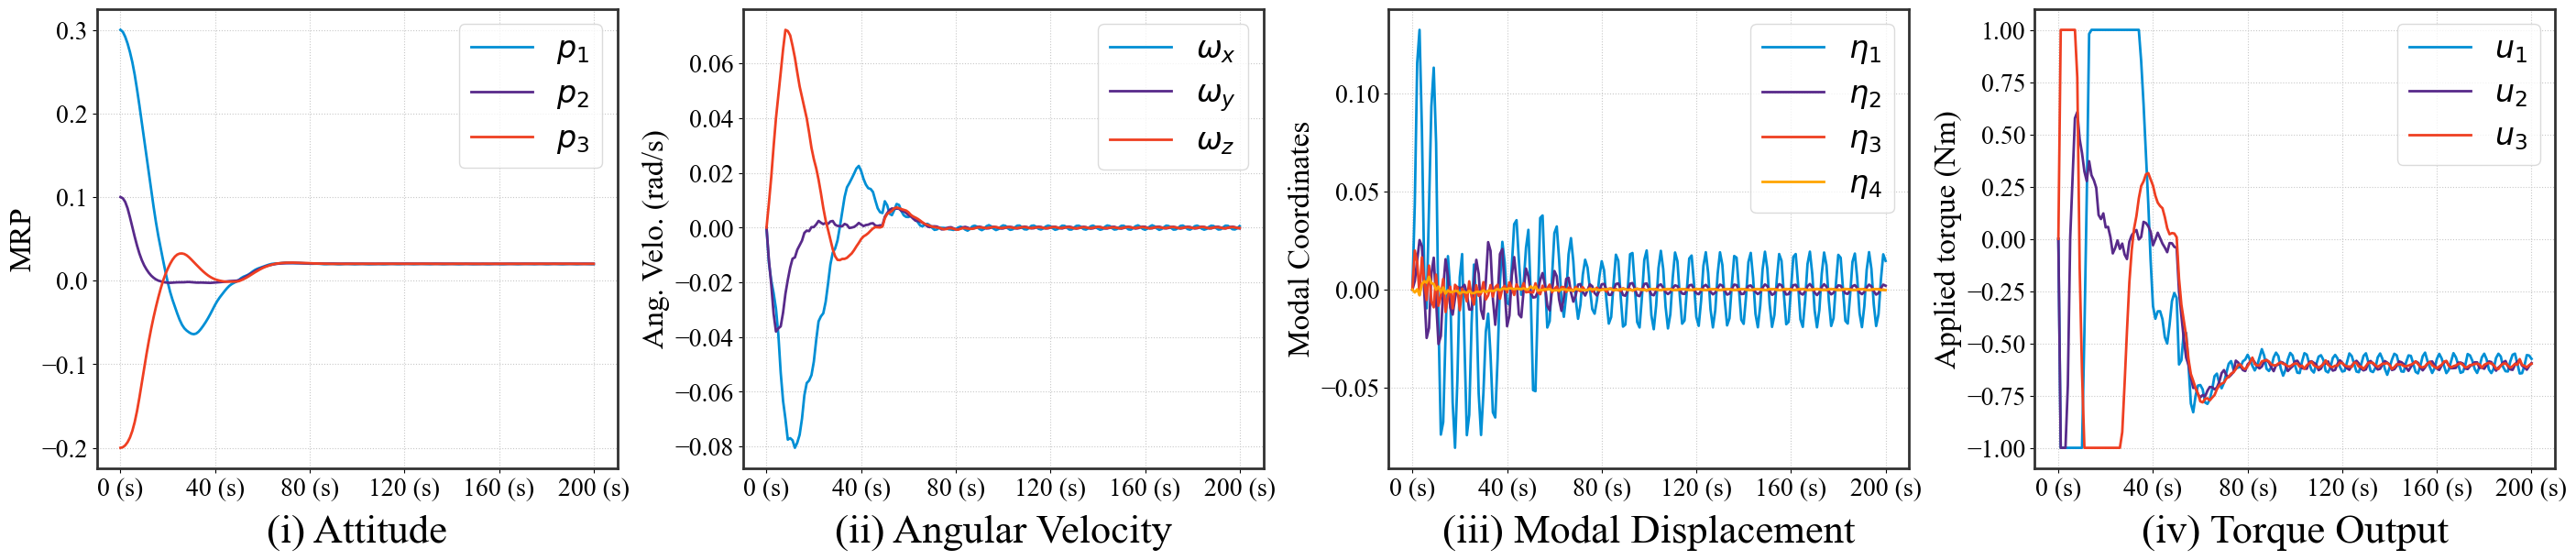

Earliest time MRP converges within 0.01 (s): None
Earliest time MRP converges within 0.005 (s): None
Earliest time angular velocity converges within 0.01 (s): 46
Earliest time angular velocity converges within 0.005 (s): 61
Maximum modal displacement: 0.132
Earliest time modal displacement converges within 0.01 (s): None
Earliest time modal displacement converges within 0.005 (s): None
  Steady-state Metrics (t > 160s)
  SS MRP ||p||_inf          : 0.020243
  SS Ang. Velo. ||ω||_inf   : 0.000843 rad/s
  SS Modal Disp. RMS        : 0.013713
  SS Control Torque RMS     : 1.042438 Nm
  Transient / Full-Trajectory Metrics
  MRP converge to 0.01 time  : Nones
  MRP converge to 0.005 time : Nones
  Full Ang. Velo. ||ω||_inf  : 0.080483 rad/s
  Full Modal Disp. RMS       : 0.029767
  Full Control Torque RMS    : 1.082157 Nm


{'converge_time_01': None,
 'converge_time_005': None,
 'omega_inf_max': np.float64(0.08048294544387544),
 'eta_rms': np.float64(0.029766855118118815),
 'torque_rms': np.float64(1.0821565517281038)}

In [34]:
mode = 'Scenario4'
episode_return = 0
env_test = FlexibleSpacecraft(200, 1, use_measurement_noise=True, use_param_uncertainty=True, use_disturbance=True)
np.random.seed(42)
state = env_test.reset(mode)
done = False
while not done:
    p = env_test.p_sensor  # Sensor MRP with noise
    omega = env_test.omega_sensor  # Sensor angular velocity with noise
    action = env_test.nominal_control(p, omega)
    env_test.Tr_sol = np.column_stack((env_test.Tr_sol, action))
    next_state, reward, done, _ = env_test.step(action)
    state = next_state
    episode_return += reward

print(f'reward for this episode: {episode_return}')
plot_states(env_test.t_sol, env_test.X_sol, env_test.Tr_sol, MDPI_style=True)
performance_old(env_test.t_sol, env_test.X_sol)
# plot_d(env_test.t_sol, env_test.d_sol)
performance_steadystate(env_test.t_sol, env_test.X_sol, env_test.Tr_sol)
performance_transient(env_test.t_sol, env_test.X_sol, env_test.Tr_sol)

### Scenario 4 performed by PD + AFT

reward for this episode: 9648.861185676358


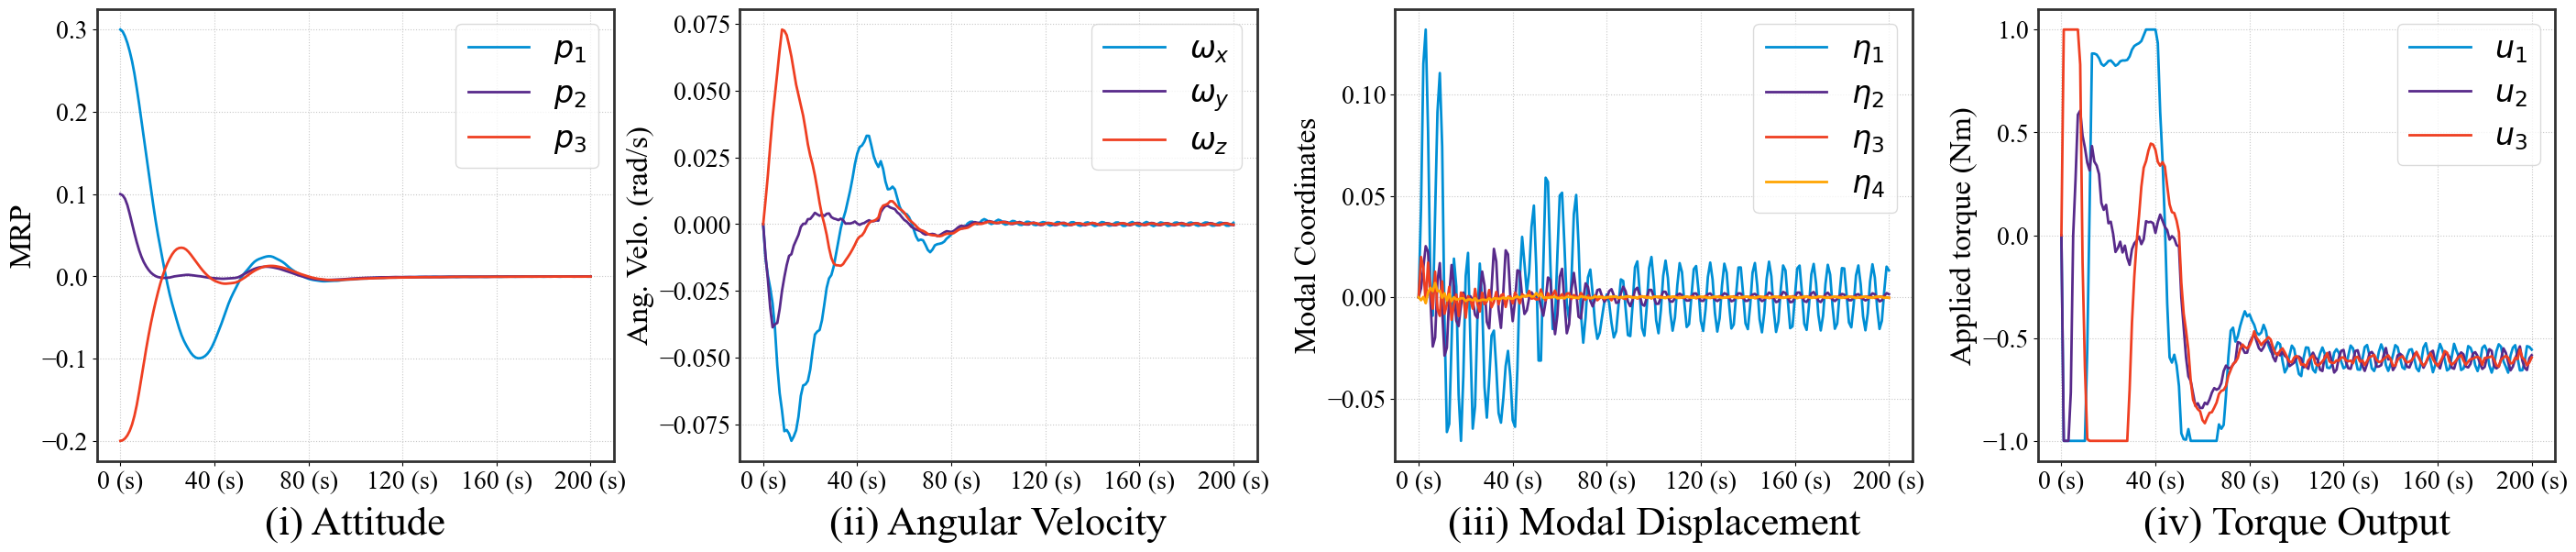

Earliest time MRP converges within 0.01 (s): 73
Earliest time MRP converges within 0.005 (s): 94
Earliest time angular velocity converges within 0.01 (s): 72
Earliest time angular velocity converges within 0.005 (s): 79
Maximum modal displacement: 0.132
Earliest time modal displacement converges within 0.01 (s): None
Earliest time modal displacement converges within 0.005 (s): None
  Steady-state Metrics (t > 160s)
  SS MRP ||p||_inf          : 0.000581
  SS Ang. Velo. ||ω||_inf   : 0.000834 rad/s
  SS Modal Disp. RMS        : 0.011673
  SS Control Torque RMS     : 1.043622 Nm
  Transient / Full-Trajectory Metrics
  MRP converge to 0.01 time  : 73s
  MRP converge to 0.005 time : 94s
  Full Ang. Velo. ||ω||_inf  : 0.081163 rad/s
  Full Modal Disp. RMS       : 0.030251
  Full Control Torque RMS    : 1.112235 Nm


{'converge_time_01': np.int64(73),
 'converge_time_005': np.int64(94),
 'omega_inf_max': np.float64(0.08116275345308387),
 'eta_rms': np.float64(0.030250744341117245),
 'torque_rms': np.float64(1.1122351797854073)}

In [35]:
mode = 'Scenario4'
episode_return = 0
env_test = FlexibleSpacecraft(200, 1, use_measurement_noise=True, use_param_uncertainty=True, use_disturbance=True)
np.random.seed(42)
state = env_test.reset(mode)
done = False
while not done:
    action = env_test.controllerAFT()
    env_test.Tr_sol = np.column_stack((env_test.Tr_sol, action))
    next_state, reward, done, _ = env_test.step(action)
    state = next_state
    episode_return += reward

print(f'reward for this episode: {episode_return}')
plot_states(env_test.t_sol, env_test.X_sol, env_test.Tr_sol, MDPI_style=True)
performance_old(env_test.t_sol, env_test.X_sol)
#plot_d(env_test.t_sol, env_test.d_sol)
performance_steadystate(env_test.t_sol, env_test.X_sol, env_test.Tr_sol)
performance_transient(env_test.t_sol, env_test.X_sol, env_test.Tr_sol)

### Test5：loss of effective fault

reward for this episode: 16620.906171358358


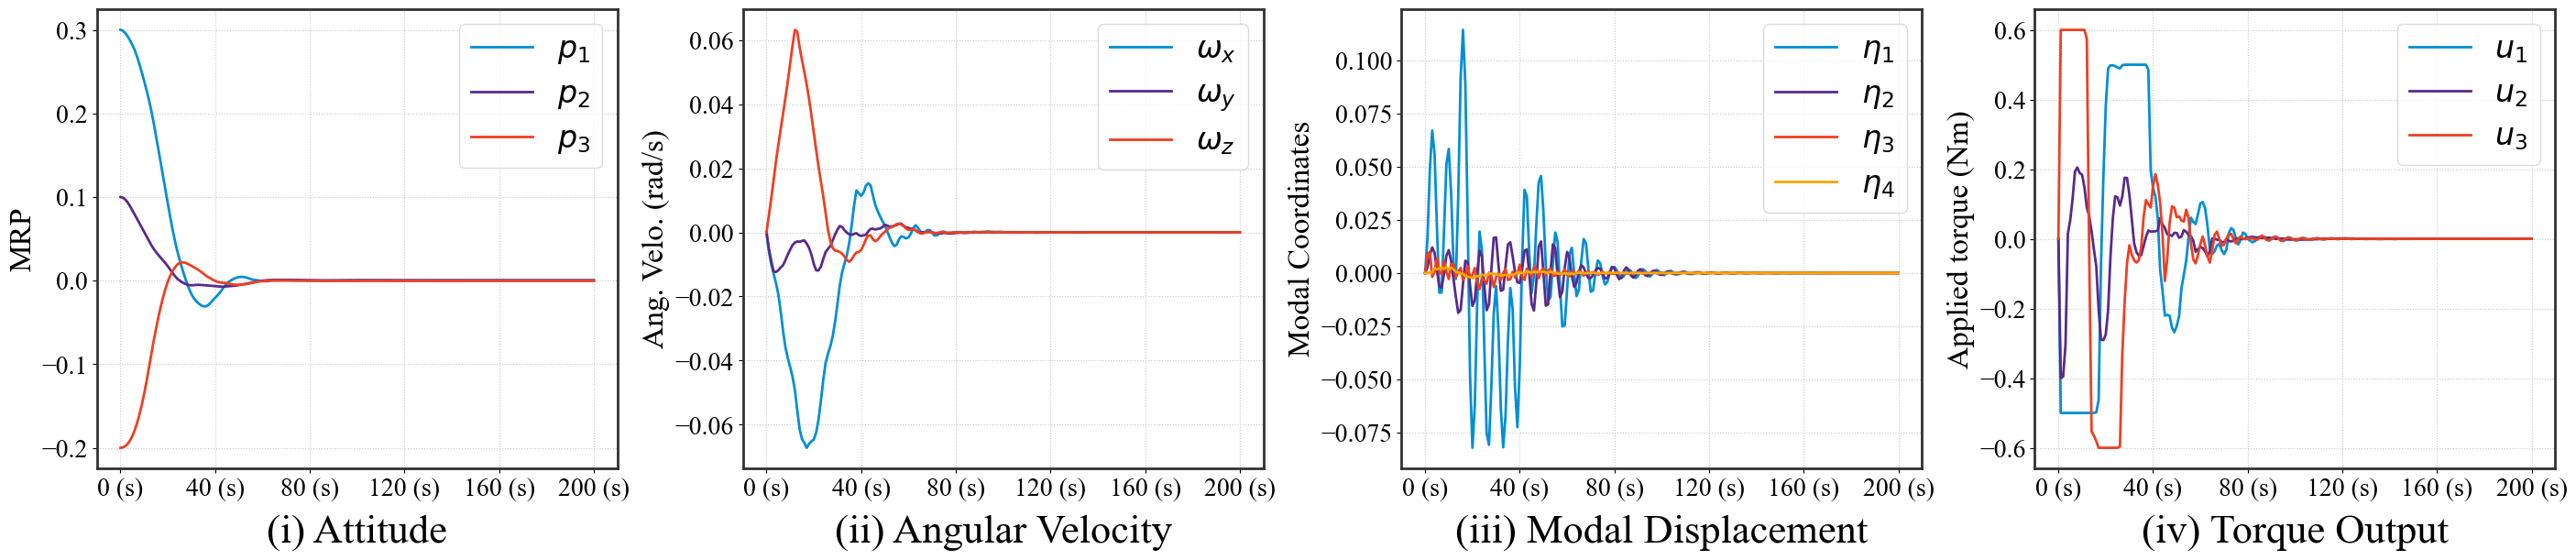

Earliest time MRP converges within 0.01 (s): 44
Earliest time MRP converges within 0.005 (s): 51
Earliest time angular velocity converges within 0.01 (s): 46
Earliest time angular velocity converges within 0.005 (s): 48
Maximum modal displacement: 0.114
Earliest time modal displacement converges within 0.01 (s): 69
Earliest time modal displacement converges within 0.005 (s): 77


In [36]:
mode = 'test5'
episode_return = 0
env_test = FlexibleSpacecraft(200, 1)
state = env_test.reset(mode)
done = False
while not done:
    action = agent.take_action(state)
    E = np.diag([0.5,0.4,0.6])
    action = E@action
    env_test.Tr_sol = np.column_stack((env_test.Tr_sol, action))
    next_state, reward, done, _ = env_test.step(action)
    state = next_state
    episode_return += reward

print(f'reward for this episode: {episode_return}')
plot_states(env_test.t_sol, env_test.X_sol, env_test.Tr_sol, MDPI_style=True)
performance_old(env_test.t_sol, env_test.X_sol)



### train mode (for reference only)

### Test 2: Impulsive Disturbance

reward for this episode: 16243.029218934238


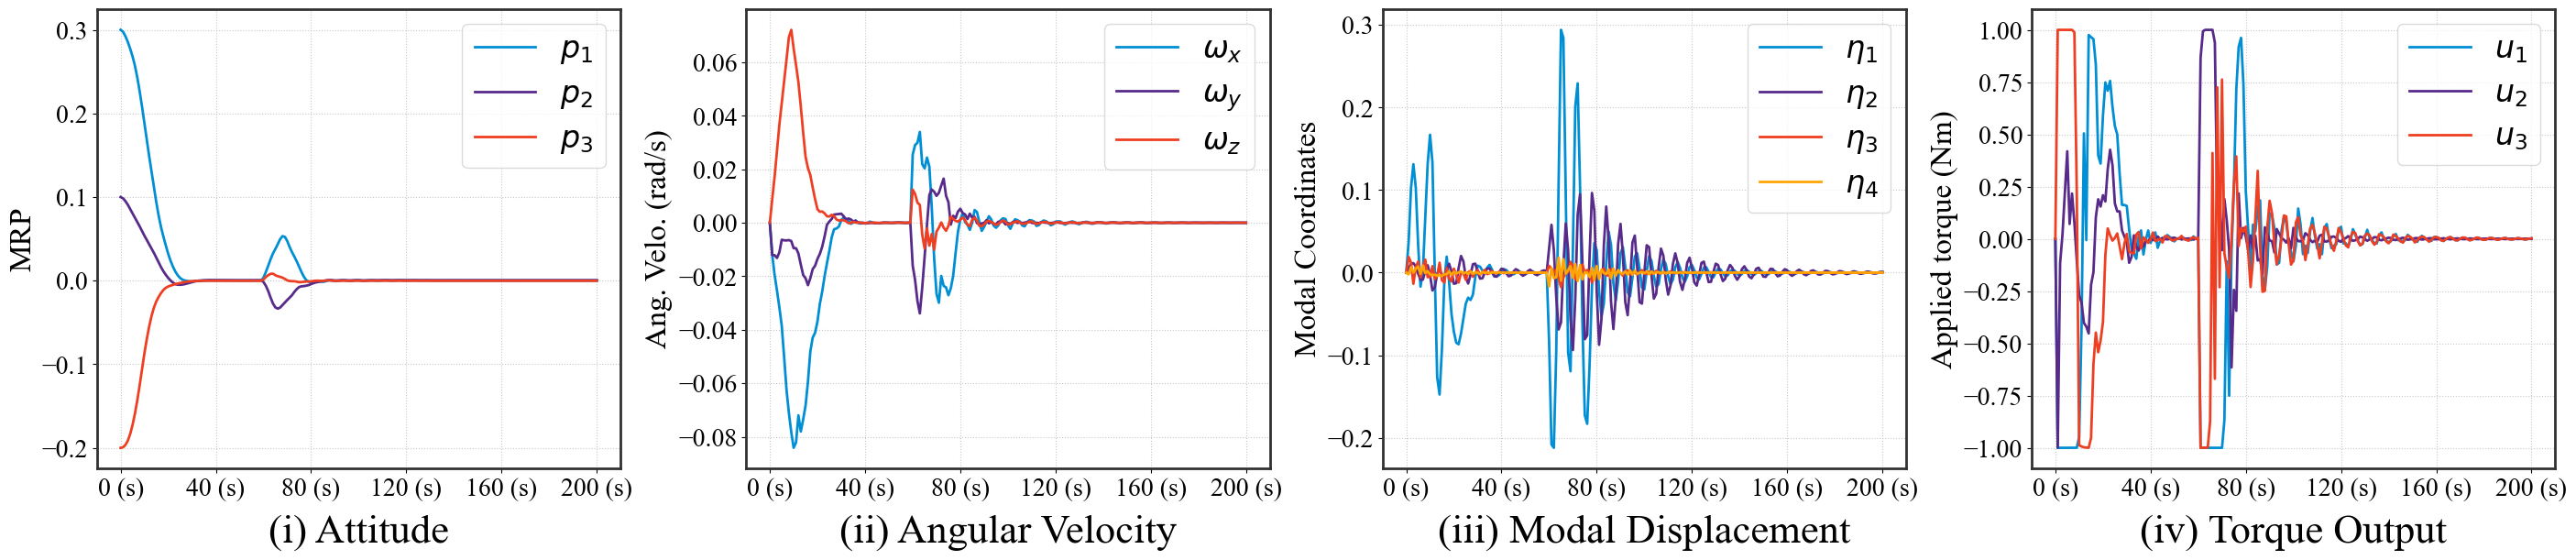

Earliest time MRP converges within 0.01 (s): 77
Earliest time MRP converges within 0.005 (s): 80
Earliest time angular velocity converges within 0.01 (s): 79
Earliest time angular velocity converges within 0.005 (s): 81
Maximum modal displacement: 0.294
Earliest time modal displacement converges within 0.01 (s): 134
Earliest time modal displacement converges within 0.005 (s): 152


In [37]:
mode = 'test2'
episode_return = 0
env_test = FlexibleSpacecraft(200, 1, use_disturbance=True)
state = env_test.reset(mode)
done = False
while not done:
    action = agent.take_action(state)
    env_test.Tr_sol = np.column_stack((env_test.Tr_sol, action))
    next_state, reward, done, _ = env_test.step(action)
    state = next_state
    episode_return += reward

print(f'reward for this episode: {episode_return}')
plot_states(env_test.t_sol, env_test.X_sol, env_test.Tr_sol, MDPI_style=True)
performance_old(env_test.t_sol, env_test.X_sol)
# plot_d(env_test.t_sol, env_test.d_sol)

### Test 3: Continuous Disturbance

reward for this episode: 10587.617822010947


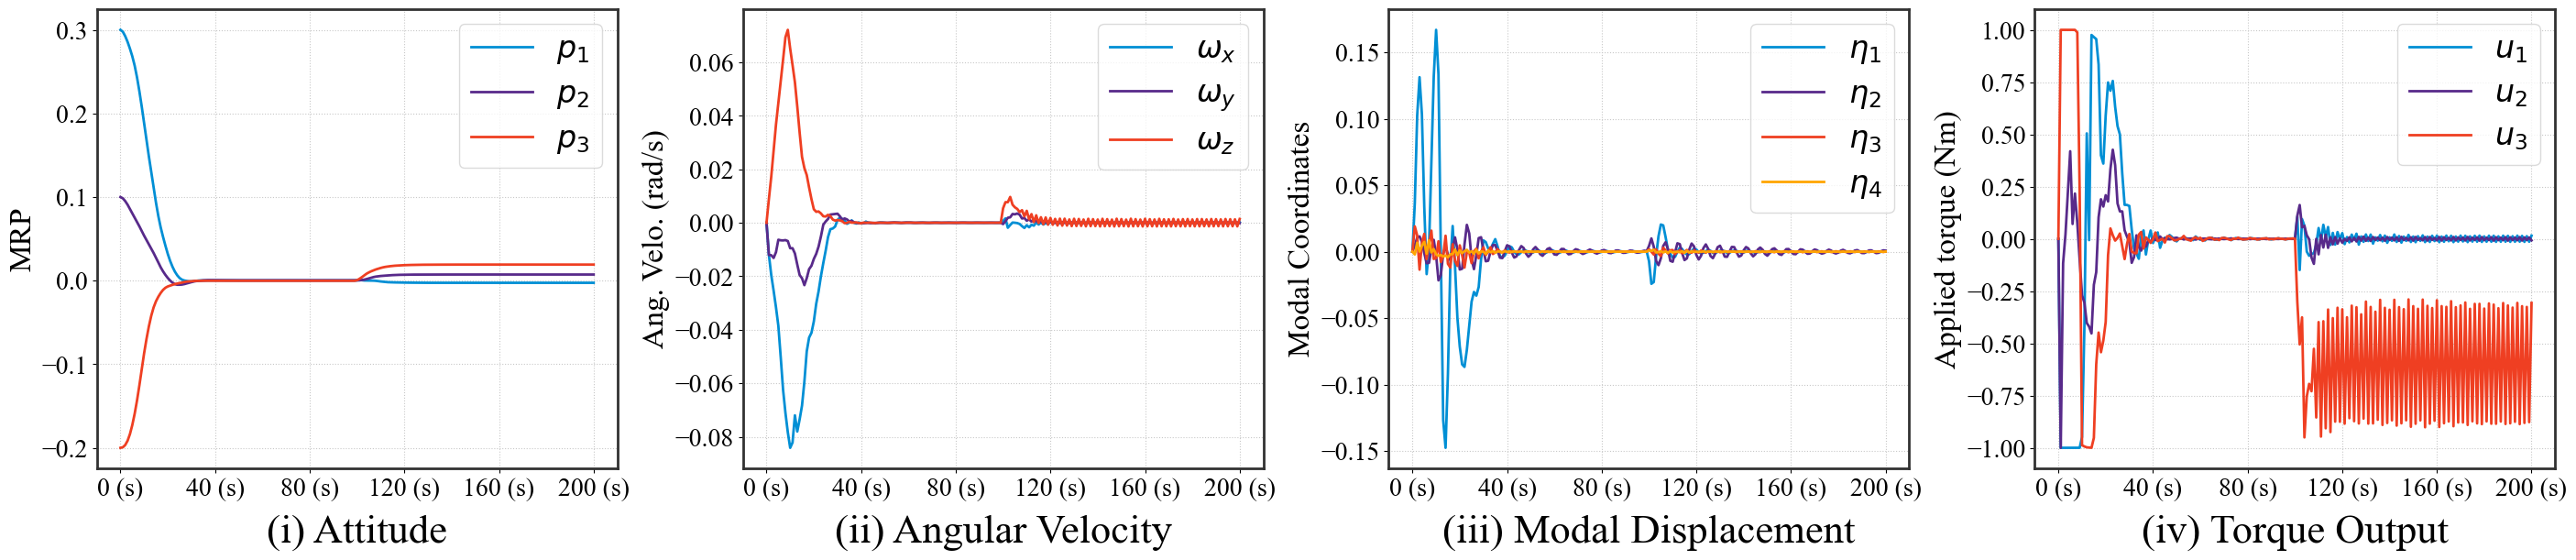

Earliest time MRP converges within 0.01 (s): None
Earliest time MRP converges within 0.005 (s): None
Earliest time angular velocity converges within 0.01 (s): 26
Earliest time angular velocity converges within 0.005 (s): 107
Maximum modal displacement: 0.167
Earliest time modal displacement converges within 0.01 (s): 108
Earliest time modal displacement converges within 0.005 (s): 125


In [38]:
mode = 'test3'
episode_return = 0
env_test = FlexibleSpacecraft(200, 1, use_disturbance=True)
state = env_test.reset(mode)
done = False
while not done:
    action = agent.take_action(state)
    env_test.Tr_sol = np.column_stack((env_test.Tr_sol, action))
    next_state, reward, done, _ = env_test.step(action)
    state = next_state
    episode_return += reward

print(f'reward for this episode: {episode_return}')
plot_states(env_test.t_sol, env_test.X_sol, env_test.Tr_sol, MDPI_style=True)
performance_old(env_test.t_sol, env_test.X_sol)
# plot_d(env_test.t_sol, env_test.d_sol)

reward for this episode: 16178.66694936971


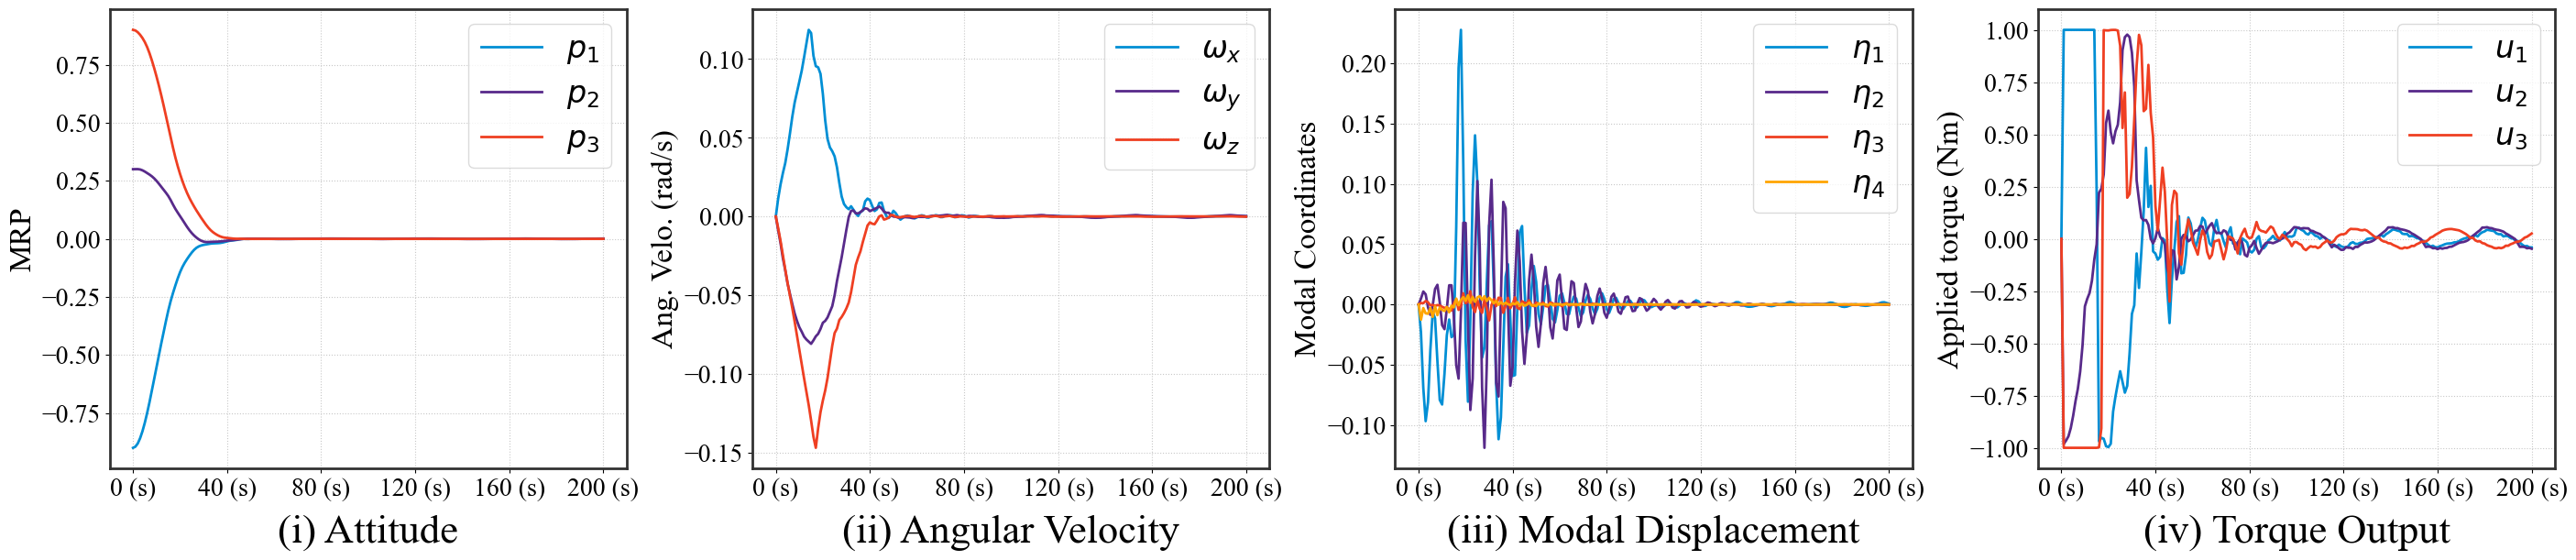

Earliest time MRP converges within 0.01 (s): 41
Earliest time MRP converges within 0.005 (s): 44
Earliest time angular velocity converges within 0.01 (s): 41
Earliest time angular velocity converges within 0.005 (s): 46
Maximum modal displacement: 0.228
Earliest time modal displacement converges within 0.01 (s): 81
Earliest time modal displacement converges within 0.005 (s): 98


In [39]:
mode = 'train'
episode_return = 0
env_test = FlexibleSpacecraft(200, 1, use_disturbance=True)
state = env_test.reset(mode)
done = False
while not done:
    action = agent.take_action(state)
    env_test.Tr_sol = np.column_stack((env_test.Tr_sol, action))
    next_state, reward, done, _ = env_test.step(action)
    state = next_state
    episode_return += reward

print(f'reward for this episode: {episode_return}')
plot_states(env_test.t_sol, env_test.X_sol, env_test.Tr_sol, MDPI_style=True)
performance_old(env_test.t_sol, env_test.X_sol)
# plot_d(env_test.t_sol, env_test.d_sol)


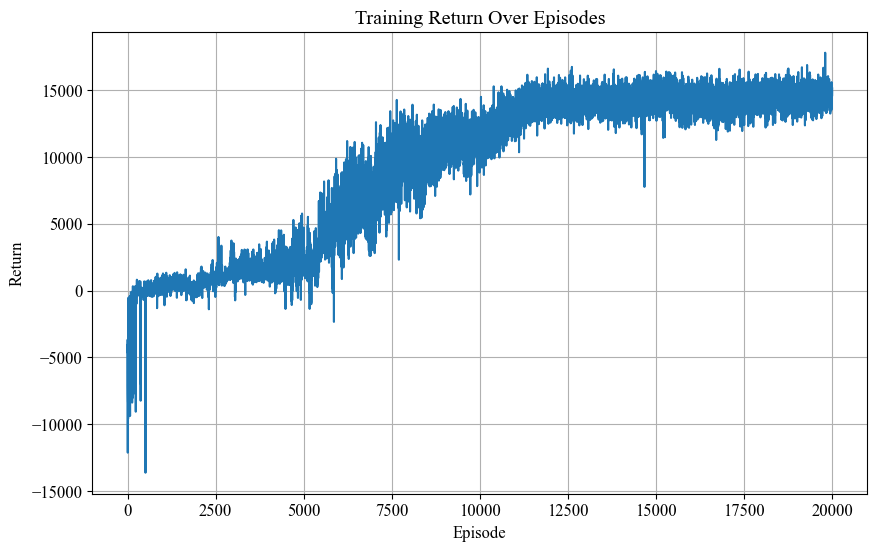

In [40]:
# Visualize training curves
import matplotlib.pyplot as plt

# Read data
return_list = np.load(os.path.join(save_path, 'return_list.npy'))

# Plot reward curve
plt.figure(figsize=(10, 6))
plt.plot(return_list)
plt.xlabel('Episode')
plt.ylabel('Return')
plt.title('Training Return Over Episodes')
plt.grid(True)
plt.show()

20000


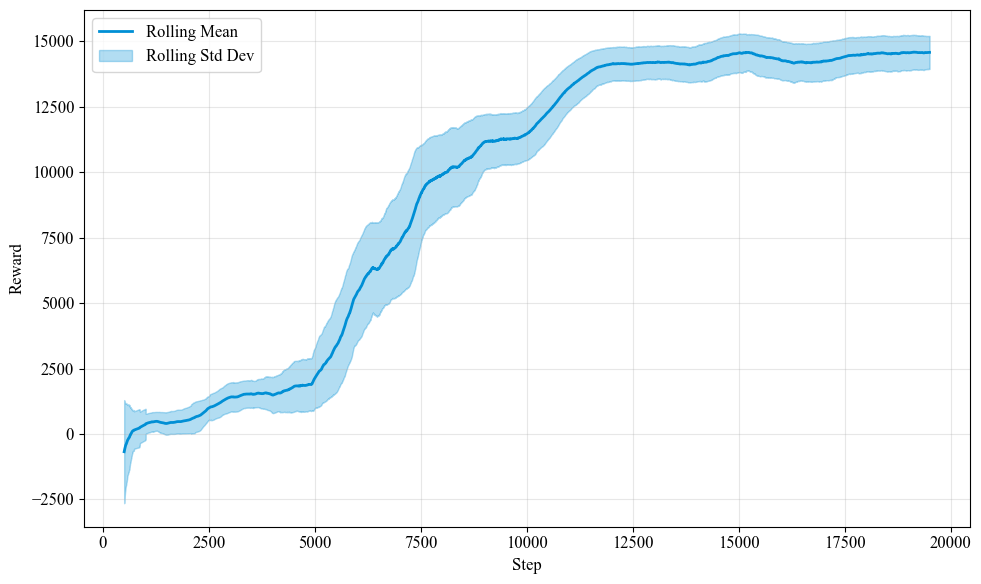

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Read numpy arrays
# Assume save_path is already defined
# save_path = 'your_path_here'
return_list = np.load(os.path.join(save_path, 'return_list.npy'))
print(len(return_list))
# Create DataFrame (if return_list is a 1-D array)
# Assume return_list contains cumulative reward per episode
df = pd.DataFrame({
    'Step': np.arange(len(return_list)),  # Create step index
    'Value': return_list                   # Use return_list as values
})

# 1-D array handling (original code logic)
mean_values = df['Value']
steps = df['Step']

# Create chart
plt.figure(figsize=(10, 6))

# Plot moving average curve
#plt.plot(steps, mean_values, linestyle='-', linewidth=2, color='blue', label='Reward')

# Show sliding window variance region if needed
window_size = max(1, len(mean_values) // 20)  # Set window size to 5% of total length
if window_size > 1:
    # Compute moving average and std dev
    rolling_mean = mean_values.rolling(window=window_size, center=True).mean()
    rolling_std = mean_values.rolling(window=window_size, center=True).std()
    
    # Plot moving average
    plt.plot(steps, rolling_mean, linestyle='-', linewidth=2, color='#008FD5', label='Rolling Mean')
    
    # Plot variance region
    plt.fill_between(steps, 
                        rolling_mean - rolling_std, 
                        rolling_mean + rolling_std, 
                        alpha=0.3, color='#008FD5', label='Rolling Std Dev')

plt.xlabel('Step')
plt.ylabel('Reward')
# plt.title('Reward History with Variance')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# Show chart
plt.show()

20000


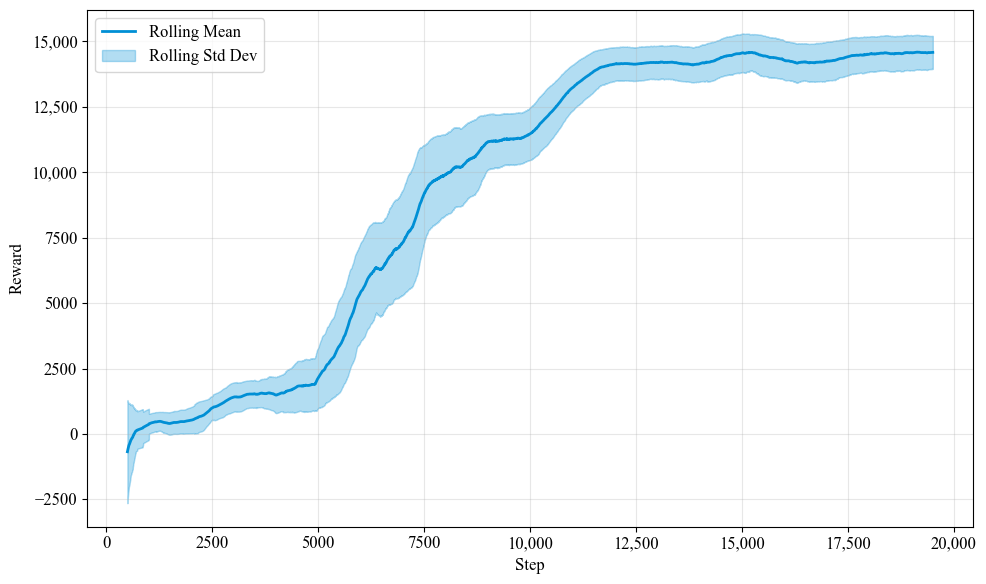

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib.ticker import FuncFormatter

# Read numpy arrays
# Assume save_path is already defined
# save_path = 'your_path_here'
return_list = np.load(os.path.join(save_path, 'return_list.npy'))
print(len(return_list))
# Create DataFrame (if return_list is a 1-D array)
# Assume return_list contains cumulative reward per episode
df = pd.DataFrame({
    'Step': np.arange(len(return_list)),  # Create step index
    'Value': return_list                   # Use return_list as values
})

# 1-D array handling (original code logic)
mean_values = df['Value']
steps = df['Step']

# Create chart
plt.figure(figsize=(10, 6))

# Plot moving average curve
#plt.plot(steps, mean_values, linestyle='-', linewidth=2, color='blue', label='Reward')

# Show sliding window variance region if needed
window_size = max(1, len(mean_values) // 20)  # Set window size to 5% of total length
if window_size > 1:
    # Compute moving average and std dev
    rolling_mean = mean_values.rolling(window=window_size, center=True).mean()
    rolling_std = mean_values.rolling(window=window_size, center=True).std()
    
    # Plot moving average
    plt.plot(steps, rolling_mean, linestyle='-', linewidth=2, color='#008FD5', label='Rolling Mean')
    
    # Plot variance region
    plt.fill_between(steps, 
                        rolling_mean - rolling_std, 
                        rolling_mean + rolling_std, 
                        alpha=0.3, color='#008FD5', label='Rolling Std Dev')

plt.xlabel('Step')
plt.ylabel('Reward')
# plt.title('Reward History with Variance')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# ---- 修改刻度标签格式 ----
def format_ticks(x, pos):
    # 对绝对值 ≥ 10000 的数字添加千位分隔符，否则保持原样（整数形式）
    if abs(x) >= 10000:
        s = f'{x:,.0f}'        # 会自动添加逗号，负号仍是 '-'
    else:
        s = f'{x:.0f}'          # 不加逗号，保留整数
    # 将连字符替换为减号 (U+2212)
    s = s.replace('-', '−')
    return s

ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(format_ticks))
ax.yaxis.set_major_formatter(FuncFormatter(format_ticks))

# Show chart
plt.show()